# CMSC 25040 Final Project: CycleGAN Image Translation

### Authors: Aeliya Grover | Robert Xing



In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
using_gpu = torch.cuda.is_available()

def load_data(data_path: str, batch_size: int = 4) -> DataLoader:
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Reduced from 256 for compute efficiency
        transforms.RandomHorizontalFlip(),  # Data augmentation
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    dataset = datasets.ImageFolder(
        root=data_path,
        transform=transform
    )

    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,  # Fixed: use the parameter instead of hardcoded 32
        shuffle=True,
        num_workers=2,  # Use 2 workers for faster loading
        pin_memory=using_gpu,
    )

    return data_loader, dataset

In [40]:
if using_gpu:
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [76]:
train_loader, train_set = load_data('./data/train')
test_loader, test_set = load_data('./data/test')

In [77]:
def output_mapping(int_label: int) -> str:
    mapping = {
        0: 'baseball',
        1: 'tennis_ball'
    }
    return mapping[int_label]

def show_img(is_train: bool, idx: int):
    if is_train:
        image, label = train_set[idx]
    else:
        image, label = test_set[idx]

    # Denormalize and convert to HWC NumPy array
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5  # Denormalize from [-1, 1] to [0, 1]
    img = img.clip(0, 1)  # Ensure valid range
    print(output_mapping(label))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

baseball


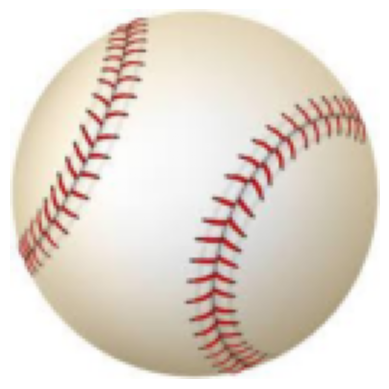

In [78]:
show_img(is_train=True, idx=0)

tennis_ball


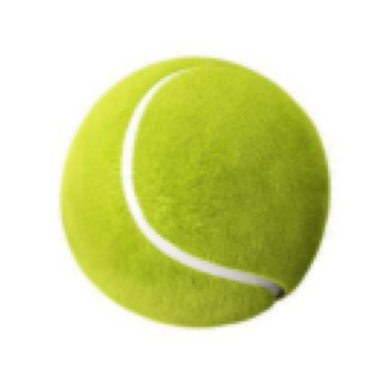

In [79]:
show_img(is_train=True, idx=400)

In [42]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 3, 3, padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return x


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 1, 4, padding=1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = self.conv3(x)
        return x

In [44]:
"""
Initalizing hyperparameters
"""
cyc_lambda = 10
lr = 0.0002
num_epochs = 1

"""
Initalizing networks + adam optimizers
"""

D_y = Discriminator().to(device)
D_x = Discriminator().to(device)

G = Generator().to(device)
F = Generator().to(device)

criterion_gan = nn.BCEWithLogitsLoss()
criterion_cyc = nn.L1Loss()

beta1, beta2 = 0.5, 0.999

optimizer_G_F = torch.optim.Adam(list(G.parameters()) + list(F.parameters()), lr=lr, betas=(beta1, beta2))
optimizer_D_X = torch.optim.Adam(D_x.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D_Y = torch.optim.Adam(D_y.parameters(), lr=lr, betas=(beta1, beta2))

real_x = real_x.to(device)
real_y = real_y.to(device)


NameError: name 'real_x' is not defined

In [ ]:
"""
Train network for a given number of epochs
The loss after every epoch is printed
"""

for e in range(num_epochs):
    D_y.train()
    D_x.train()
    G.train()
    F.train()


    fake_y = G(real_x)
    fake_x = F(real_y)

    cycled_x = F(fake_y)
    cycled_y = G(fake_x)


    #d_y
    optimizer_D_Y.zero_grad()

    pred_real_y = D_y(real_y)
    real_label_y = torch.ones_like(pred_real_y)
    loss_dy_real = criterion_gan(pred_real_y, real_label_y)

    pred_fake_y = D_y(fake_y.detach())
    fake_label_y = torch.zeros_like(pred_fake_y)
    loss_dy_fake = criterion_gan(pred_fake_y, fake_label_y)

    loss_DY = 0.5 * (loss_dy_real + loss_dy_fake)
    loss_DY.backward()
    optimizer_D_Y.step()


    # d_x
    optimizer_D_X.zero_grad()

    pred_real_x = D_x(real_x)
    real_label_x = torch.ones_like(pred_real_x)
    loss_dx_real = criterion_gan(pred_real_x, real_label_x)

    pred_fake_x = D_x(fake_x.detach())
    fake_label_x = torch.zeros_like(pred_fake_x)
    loss_dx_fake = criterion_gan(pred_fake_x, fake_label_x)

    loss_DX = 0.5 * (loss_dx_real + loss_dx_fake)
    loss_DX.backward()
    optimizer_D_X.step()

    # cycle consistency + generator loss
    optimizer_G_F.zero_grad()

    pred_fake_y_for_G = D_y(fake_y)
    loss_G_adv = criterion_gan(pred_fake_y_for_G, torch.ones_like(pred_fake_y_for_G))

    pred_fake_x_for_F = D_x(fake_x)
    loss_F_adv = criterion_gan(pred_fake_x_for_F, torch.ones_like(pred_fake_x_for_F))

    loss_cycle_x = criterion_cyc(cycled_x, real_x)
    loss_cycle_y = criterion_cyc(cycled_y, real_y)
    loss_cycle = loss_cycle_x + loss_cycle_y

    loss_G_total = loss_G_adv + loss_F_adv + cyc_lambda * loss_cycle
    loss_G_total.backward()
    optimizer_G_F.step()

    print({"loss_DX"loss_DX.item(), \
        "loss_DY": loss_DY.item(), \
        "loss_G_adv": loss_G_adv.item(), \
        "loss_F_adv": loss_F_adv.item(), \
        "loss_cycle": loss_cycle.item(), \
        "loss_G_total": loss_G_total.item()})
